In [46]:
%pip install langchain_community 

Note: you may need to restart the kernel to use updated packages.


In [47]:
##tools
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper

In [48]:
%pip install arxiv

Note: you may need to restart the kernel to use updated packages.


In [49]:
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv, description="query arxiv papers")
print(arxiv.name)

arxiv


In [50]:
arxiv.invoke("what is this document about")

'Published: 2023-09-11\nTitle: Long-Range Transformer Architectures for Document Understanding\nAuthors: Thibault Douzon, Stefan Duffner, Christophe Garcia, Jérémy Espinas\nSummary: Since their release, Transformers have revolutionized many fields from Natural Language Understanding to Computer Vision. Document Understanding (DU) was not left behind with first Transformer based models for DU dating from late 2019. However, the computational complexity of the self-attention operation limits their cap'

In [51]:
arxiv.invoke("what is the latest research on quantum computing")

'Published: 2025-04-07\nTitle: Quantum Computing: Vision and Challenges\nAuthors: Sukhpal Singh Gill, Oktay Cetinkaya, Stefano Marrone, Daniel Claudino, David Haunschild, Leon Schlote, Huaming Wu, Carlo Ottaviani, Xiaoyuan Liu, Sree Pragna Machupalli, Kamalpreet Kaur, Priyansh Arora, Ji Liu, Ahmed Farouk, Houbing Herbert Song, Steve Uhlig, Kotagiri Ramamohanarao\nSummary: The recent development of quantum computing, which uses entanglement, superposition, and other quantum fundamental concepts, can '

In [54]:
%pip install wikipedia

Note: you may need to restart the kernel to use updated packages.


In [55]:
api_wrapper_wiki=WikipediaAPIWrapper()

wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
print(wiki.name)

wikipedia


tavily-used to connect the llm to web

groq-groq is a ai company known for high speed language processing unit and cloud service it makes chatbots fast and alowing it to process large language models at extremely high token speed at low cost

In [56]:
from dotenv import load_dotenv
import os

load_dotenv()

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [57]:
from langchain_community.tools.tavily_search import TavilySearchResults

tavily =  TavilySearchResults()

In [58]:
tavily.invoke("latest news on artificial intelligence")

[{'title': 'Artificial intelligence | Massachusetts Institute of Technology',
  'url': 'https://news.mit.edu/topic/artificial-intelligence2',
  'content': 'The AI-powered tool could inform the design of better sensors and cameras for robots or autonomous vehicles.\n\nDecember 17, 2025\n\nRead full story →\n\nA chair made of modular lattice cubes.\n\n### “Robot, make me a chair”\n\nAn AI-driven system lets users design and build simple, multicomponent objects by describing them with words.\n\nDecember 16, 2025\n\nRead full story →\n\nYunha Hwang stands on Hockfield Court at MIT in front of a large, red sculpture fashioned from I-beams [...] December 18, 2025\n\nRead full story →\n\n6 cartoon illustrations of cats in various interactions with a cardboard box.\n\n### A new way to increase the capabilities of large language models\n\nMIT-IBM Watson AI Lab researchers developed an expressive architecture that provides better state tracking and sequential reasoning in LLMs over long texts.\n

In [59]:

##combine all these tools in the list
tools=[arxiv,wiki,tavily]

In [60]:
%pip install langchain_groq


Note: you may need to restart the kernel to use updated packages.


In [61]:
##initizlize the llm model
from langchain_groq import ChatGroq

llm = ChatGroq(model="llama-3.3-70b-versatile")

In [62]:
llm.invoke("what is ai")

AIMessage(content='**Artificial Intelligence (AI)**: Artificial Intelligence refers to the development of computer systems that can perform tasks that typically require human intelligence, such as:\n\n1. **Learning**: The ability to learn from data and improve performance over time.\n2. **Problem-solving**: The ability to solve complex problems using reasoning and decision-making.\n3. **Perception**: The ability to interpret and understand data from sensors, such as images, speech, and text.\n4. **Reasoning**: The ability to draw inferences and make decisions based on available data.\n\n**Key Characteristics of AI:**\n\n1. **Intelligence**: AI systems can perform tasks that typically require human intelligence.\n2. **Autonomy**: AI systems can operate independently, making decisions without human intervention.\n3. **Adaptability**: AI systems can adapt to new situations and learn from experience.\n\n**Types of AI:**\n\n1. **Narrow or Weak AI**: Designed to perform a specific task, such

In [63]:
%pip install langchain

Note: you may need to restart the kernel to use updated packages.


In [64]:
from langchain.tools import tool

In [65]:
from typing_extensions import TypedDict ##for entire state which we create
from langchain_core.messages import AnyMessage ## human message and ai message
from typing import Annotated ##labelling
from langgraph.graph.message import add_messages ##resucers in langgraph

In [66]:
class State(TypedDict):
    messages:Annotated[list[AnyMessage], add_messages]

In [67]:
%pip install langchain 

Note: you may need to restart the kernel to use updated packages.


In [69]:
%pip install pyppeteer nest_asyncio

Note: you may need to restart the kernel to use updated packages.


In [70]:
###Entire chatbot with langgraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langchain.tools import tool


In [71]:
# in notebook or terminal with your venv active
%pip install pyppeteer nest_asyncio

Note: you may need to restart the kernel to use updated packages.


In [72]:
%pip install groq langchain-groq

Note: you may need to restart the kernel to use updated packages.


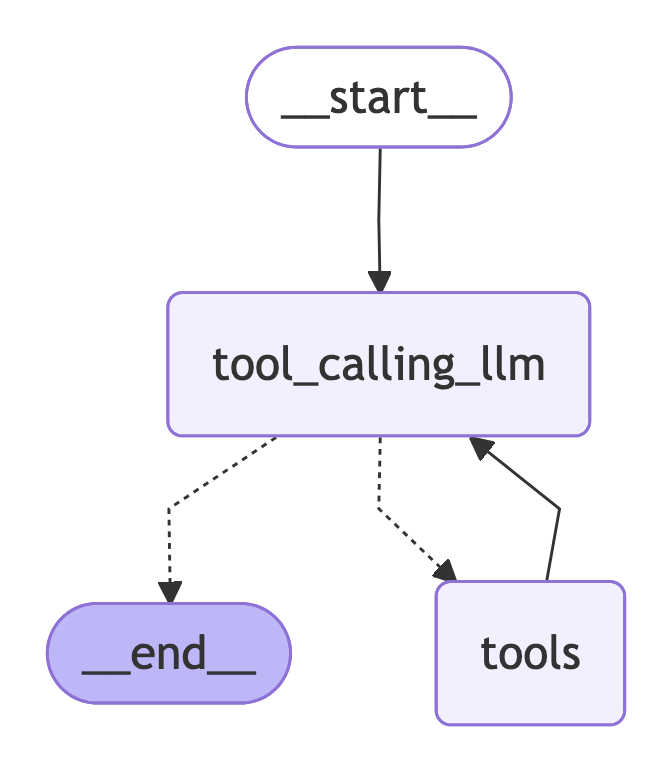

In [84]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_groq import ChatGroq
from langchain_core.runnables.graph import MermaidDrawMethod
from IPython.display import Image, display
import nest_asyncio
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.tools import tool

nest_asyncio.apply()

# ---------------- LLM ----------------
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)

llm_with_tools = llm.bind_tools(tools)

# ensure tools exists (paste at top of the graph cell)
try:
    tools
except NameError:
    try:
        tools = [arxiv, wiki, tavily]
    except NameError as e:
        raise NameError(
            "Missing tool objects. Run the cells that create `arxiv`, `wiki`, and `tavily` "
            "before building the graph."
        ) from e
    
# ---------------- NODES ----------------
def tool_calling_llm(state: State):
    msg = llm_with_tools.invoke(state["messages"])
    return {"messages": state["messages"] + [msg]}


# ---------------- GRAPH ----------------
builder = StateGraph(State)

builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))


builder.add_edge(START, "tool_calling_llm")

builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)

builder.add_edge("tools", "tool_calling_llm")
builder.add_edge("tool_calling_llm", END)



graph = builder.compile()


# ---------------- DRAW GRAPH ----------------
display(
    Image(
        graph.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.PYPPETEER
        )
    )
)



# Correct invocation (run after the cell above)
from langchain_core.messages import HumanMessage  # or from langchain.schema import HumanMessage if needed

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)

state = {"messages": [HumanMessage(content="1706.03762")]}
out_state = tool_calling_llm(state) 

print(out_state)
msg = out_state["messages"][0]
try:
    msg.pretty_print()
except Exception:
    print(msg) 

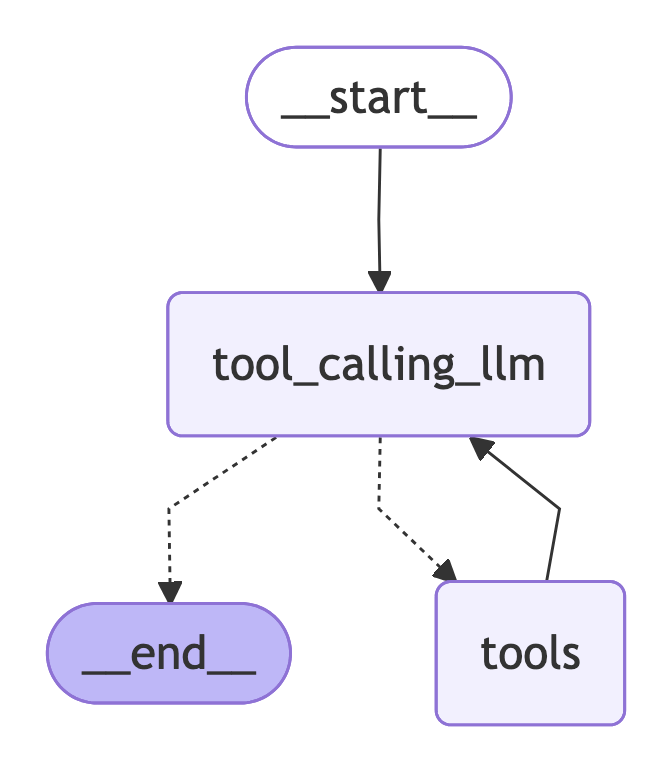

In [85]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_groq import ChatGroq
from langchain_core.runnables.graph import MermaidDrawMethod
from IPython.display import Image, display
import nest_asyncio
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.tools import tool


nest_asyncio.apply()

# ---------------- LLM ----------------
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)

llm_with_tools = llm.bind_tools(tools)

# ensure tools exists (paste at top of the graph cell)
try:
    tools
except NameError:
    try:
        tools = [arxiv, wiki, tavily]
    except NameError as e:
        raise NameError(
            "Missing tool objects. Run the cells that create `arxiv`, `wiki`, and `tavily` "
            "before building the graph."
        ) from e
    
# ---------------- NODES ----------------
def tool_calling_llm(state: State):
    msg = llm_with_tools.invoke(state["messages"])
    return {"messages": state["messages"] + [msg]}

# ---------------- GRAPH ----------------
builder = StateGraph(State)

builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))


builder.add_edge(START, "tool_calling_llm")

builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)

builder.add_edge("tools", "tool_calling_llm")
builder.add_edge("tool_calling_llm", END)

graph = builder.compile()

# ---------------- DRAW GRAPH ----------------
display(
    Image(
        graph.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.PYPPETEER
        )
    )
)


In [86]:
# Correct invocation (run after the cell above)
from langchain_core.messages import HumanMessage  # or from langchain.schema import HumanMessage if needed

llm_with_tools = llm
state = {"messages": [HumanMessage(content="my name is revati patil")]}
out_state = tool_calling_llm(state)

print(out_state)
msg = out_state["messages"][0]
try:
    msg.pretty_print()
except Exception:
    print(msg) 

{'messages': [HumanMessage(content='my name is revati patil', additional_kwargs={}, response_metadata={}), AIMessage(content='Nice to meet you, Revati Patil. How can I assist you today? Is there something I can help you with or would you like to chat?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_tokens': 42, 'total_tokens': 75, 'completion_time': 0.085445476, 'completion_tokens_details': None, 'prompt_time': 0.001229286, 'prompt_tokens_details': None, 'queue_time': 0.054019024, 'total_time': 0.086674762}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_c06d5113ec', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019b5e1c-e657-7be0-89eb-4b4ff6ce5a30-0', usage_metadata={'input_tokens': 42, 'output_tokens': 33, 'total_tokens': 75})]}
================================ Human Message =================================

my name is revati patil


In [87]:
messages=graph.invoke({"messages": "hii my name is revati"})
for msg in messages["messages"]:
    try:
        msg.pretty_print()
    except Exception:
        print(msg)

================================ Human Message =================================

hii my name is revati
================================== Ai Message ==================================

Hello Revati, it's nice to meet you. Is there something I can help you with or would you like to chat?


In [88]:
messages=graph.invoke({"messages": "what is the recent ai news and then please tell me the recent research paper on quantum computing"})
for msg in messages["messages"]:
    try:
        msg.pretty_print()
    except Exception:
        print(msg)

================================ Human Message =================================

what is the recent ai news and then please tell me the recent research paper on quantum computing
================================== Ai Message ==================================

**Recent AI News:**

1. **Google's Gemini AI Model**: Google has announced its new AI model, Gemini, which is a large language model that can understand and generate human-like text. Gemini is designed to be more efficient and accurate than previous models, and it has the potential to revolutionize the field of natural language processing.
2. **Meta's Llama AI Model**: Meta has released its new AI model, Llama, which is a large language model that can understand and generate human-like text. Llama is designed to be more efficient and accurate than previous models, and it has the potential to revolutionize the field of natural language processing.
3. **AI-generated Art**: AI-generated art has been making headlines recently, with 

In [89]:
messages=graph.invoke({"messages": "what is the latest news in india also tell "})
for msg in messages["messages"]:
    try:
        msg.pretty_print()
    except Exception:
        print(msg)

================================ Human Message =================================

what is the latest news in india also tell 
================================== Ai Message ==================================

As my knowledge cutoff is March 2023, I'll provide you with some of the latest news in India up to that date. Please note that the news may have changed since then.

**Latest News in India (as of March 2023):**

1. **Budget 2023:** The Indian government presented the Union Budget 2023, which focused on boosting economic growth, infrastructure development, and social welfare schemes.
2. **Adani Group Crisis:** The Adani Group, a major Indian conglomerate, faced a significant crisis after a report by Hindenburg Research alleged financial irregularities and corporate governance issues.
3. **India's G20 Presidency:** India assumed the presidency of the G20, a grouping of the world's 20 largest economies, with a focus on promoting global economic cooperation and addressing pressing issu

In [81]:
messages=graph.invoke({"messages": "tell me who is albert einstein and what are the recent research papers on quantum physics"})
for msg in messages["messages"]:
    try:
        msg.pretty_print()
    except Exception:
        print(msg)

================================ Human Message =================================

tell me who is albert einstein and what are the recent research papers on quantum physics
================================== Ai Message ==================================

**Who is Albert Einstein?**

Albert Einstein (1879-1955) was a renowned German-born physicist who is widely regarded as one of the most influential scientists of the 20th century. He is best known for his theory of relativity and the famous equation E=mc², which describes the relationship between energy and mass. Einstein's work revolutionized our understanding of space, time, and gravity, and his contributions to physics are still widely studied and built upon today.

Einstein's notable contributions include:

1. **Special Relativity (1905)**: Introduced the concept of time dilation, length contraction, and the speed of light as a universal constant.
2. **General Relativity (1915)**: Described gravity as the curvature of spacetime caus

In [82]:
messages=graph.invoke({"messages": "tell me why the ai is important"})
for msg in messages["messages"]:
    try:
        msg.pretty_print()
    except Exception:
        print(msg)

================================ Human Message =================================

tell me why the ai is important
================================== Ai Message ==================================

Artificial Intelligence (AI) is important for several reasons:

1. **Automation and Efficiency**: AI can automate repetitive and mundane tasks, freeing up human time and increasing productivity. This can lead to significant cost savings and improved efficiency in various industries, such as manufacturing, healthcare, and finance.
2. **Data Analysis and Insights**: AI can analyze vast amounts of data quickly and accurately, providing valuable insights that can inform business decisions, improve customer experiences, and drive innovation.
3. **Personalization and Customer Experience**: AI-powered systems can learn individual preferences and behaviors, enabling personalized recommendations, tailored marketing, and enhanced customer experiences.
4. **Healthcare and Medical Research**: AI can help 

In [ ]:
messages=graph.invoke({"messages": "why the ai is taking jobs of people"})
for msg in messages["messages"]:
    try:
        msg.pretty_print()
    except Exception:
        print(msg)

================================ Human Message =================================

why the ai is taking place of jobs 
================================== Ai Message ==================================

The increasing presence of Artificial Intelligence (AI) in the workforce is a complex and multifaceted issue. Here are some reasons why AI is taking the place of some jobs:

1. **Automation**: AI can perform repetitive, mundane, and time-consuming tasks with greater speed and accuracy than humans. This makes it an attractive option for companies looking to streamline their operations and reduce labor costs.
2. **Efficiency**: AI can analyze vast amounts of data, identify patterns, and make decisions faster and more accurately than humans. This enables businesses to optimize their processes, improve productivity, and reduce errors.
3. **Cost savings**: Implementing AI solutions can help companies reduce labor costs, as they can automate tasks that would otherwise require human workers. This

In [83]:
messages=graph.invoke({"messages": "is ai is going to be in trend in 5 6 years also and how many job it will takeplace in 5 6 years is this that importatnt "})
for msg in messages["messages"]:
    try:
        msg.pretty_print()
    except Exception:
        print(msg)

================================ Human Message =================================

is ai is going to be in trend in 5 6 years also and how many job it will takeplace in 5 6 years is this that importatnt 
================================== Ai Message ==================================

Yes, AI is expected to continue to be a significant trend in the next 5-6 years, and its impact on the job market will be substantial. Here are some predictions and insights:

**Trend continuation:**

1. **Growth in AI adoption**: AI will continue to be adopted across various industries, including healthcare, finance, transportation, and education.
2. **Increased investment**: Investment in AI research and development is expected to increase, driving innovation and advancements in the field.
3. **Expansion of AI applications**: AI will be applied to new areas, such as edge computing, explainable AI, and human-AI collaboration.

**Job market impact:**

1. **Job displacement**: According to a report by the M